In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
#loading the dataset
df = pd.read_csv(r"C:\Users\sanke\Downloads\StudentsPerformance.csv")

#reading the first five rows of the dataset
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
#checking the available colums in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
print("Summary statistics :")
df.describe()
 

Summary statistics :


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
#data cleaning : checking for missing values 
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [ ]:
#creating an average score for each and every student
df['Average_score']= df[['math score','reading score','writing score']].mean(axis=1)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [7]:
#performing the Analysis
#checking gender distribution
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [8]:
#computing average scores by gender
gender_means = df.groupby('gender')[['math score','reading score','writing score']].mean()
gender_means

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


### Comparing the male-female perfomance in the subjects 
-In maths the male performance is better compared to the female gender perfomance
-In reading the female gender performance is higher  compared to the male gender perfomance
-In writing the female gender performance is a lot higher compared to the male gender perfomance

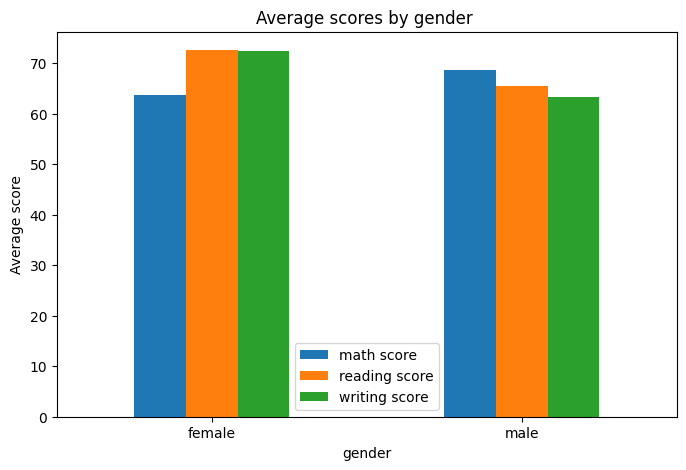

In [9]:
#Visualizing the comparison using a bar plot 
gender_means.plot(kind='bar',figsize=(8,5))
plt.title("Average scores by gender ")
plt.ylabel("Average score")
plt.xticks(rotation =0)
plt.show()

In [10]:
#checking how test preparation affects the performance
df['test preparation course'].value_counts()


test preparation course
none         642
completed    358
Name: count, dtype: int64

In [11]:
#means scores by test preparation 
prep_means = df.groupby('test preparation course')[['math score','reading score','writing score']].mean()
prep_means

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


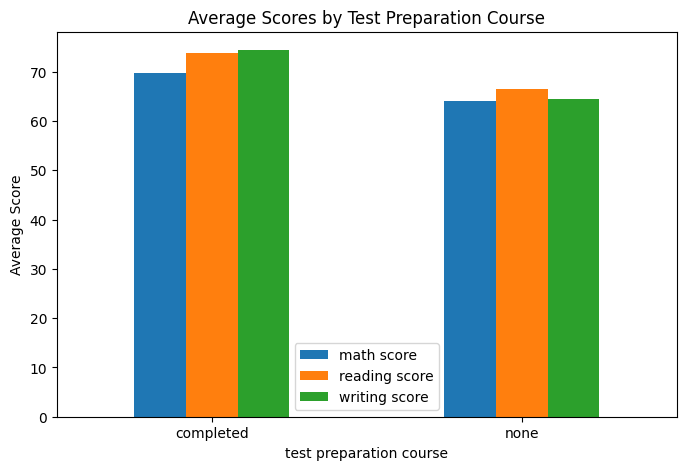

In [12]:
prep_means.plot(kind='bar', figsize=(8,5))
plt.title("Average Scores by Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()


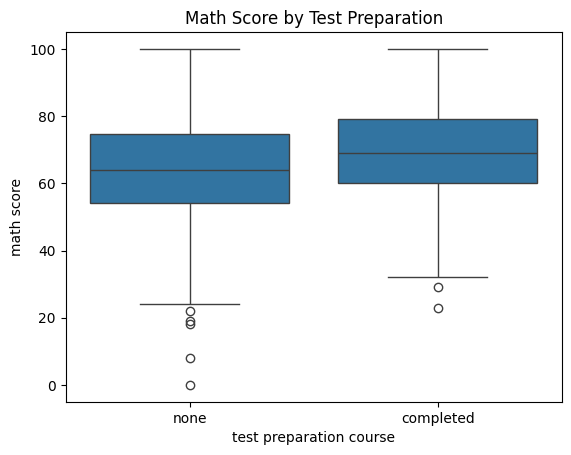

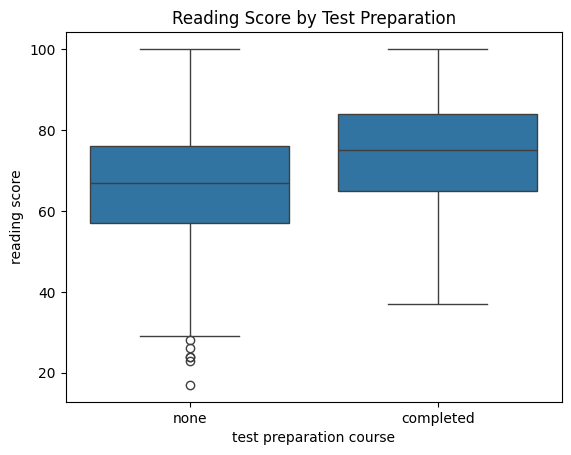

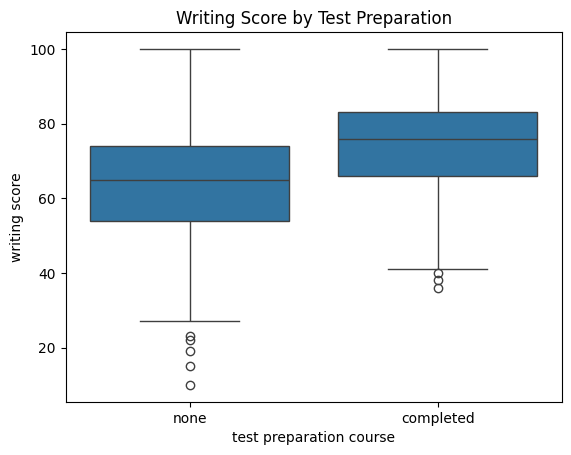

In [13]:
#distribution insights using a boxplot
subjects = ['math score','reading score','writing score']
for subject in subjects:
    sns.boxplot(x='test preparation course',y = subject , data = df)
    plt.title(f"{subject.title()} by Test Preparation")
    plt.show()

In [14]:
#Doing the statistical test using the p-value to test the null hypothesis
from scipy.stats import ttest_ind

for subject in subjects:
    completed = df[df['test preparation course'] == 'completed'][subject]
    none = df[df['test preparation course'] == 'none'][subject]

    t_stat,p_val =  ttest_ind(completed,none)
    print(f"{subject}: p-value = {p_val:.5f}")

math score: p-value = 0.00000
reading score: p-value = 0.00000
writing score: p-value = 0.00000


 ### Effect of Test Preparation Course
- Students who completed the test preparation course scored higher in all three subjects.
- The largest performance gap is observed in Mathematics.
- Statistical tests confirm that the differences are significant (p < 0.05) for each subject 


In [15]:
#checking how parental level of eduaction affects the students perfomance
#checking what categroies are available
df['parental level of education'].value_counts()


parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [16]:
edu_means = df.groupby('parental level of education')[['math score','reading score','writing score']].mean()
edu_means

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [17]:
#sorting the means using maths score 
edu_means_sorted = edu_means.sort_values(by = 'math score')
edu_means_sorted

,math score,reading score,writing score
parental level of education,,,
high school,62.137755,64.704082,62.448980
some high school,63.497207,66.938547,64.888268
some college,67.128319,69.460177,68.840708
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
master's degree,69.745763,75.372881,75.677966


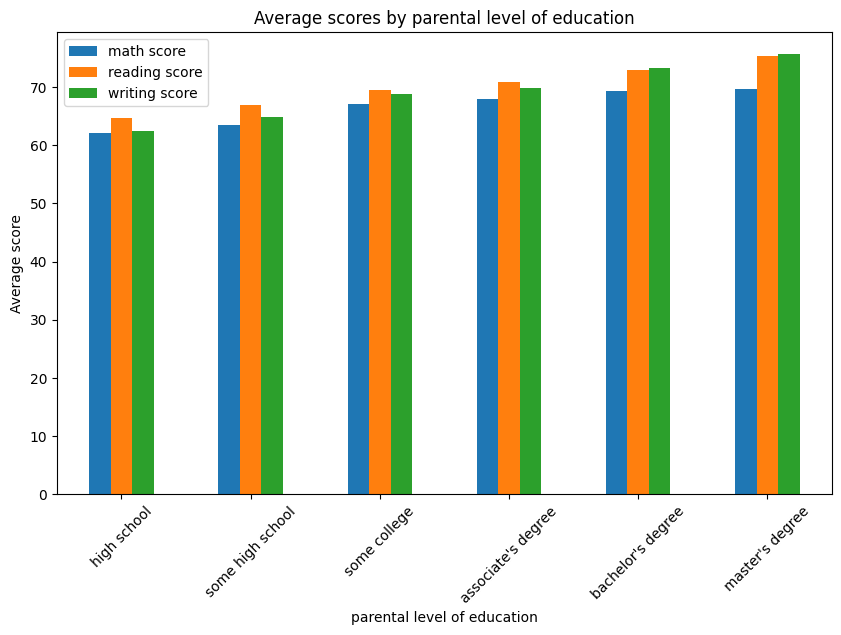

In [18]:
#visualisation (bar chart)
edu_means_sorted.plot(kind = 'bar',figsize =(10,6))
plt.title("Average scores by parental level of education")
plt.ylabel("Average score")
plt.xticks(rotation = 45)
plt.show()

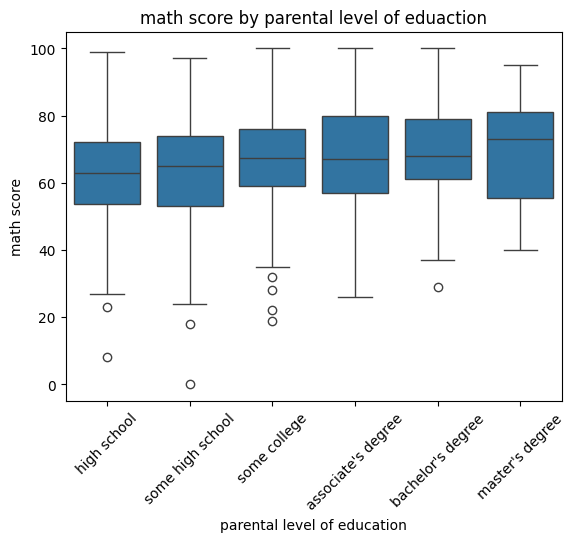

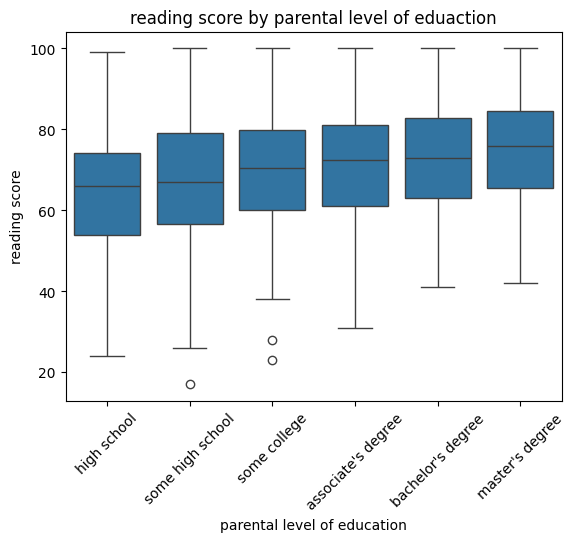

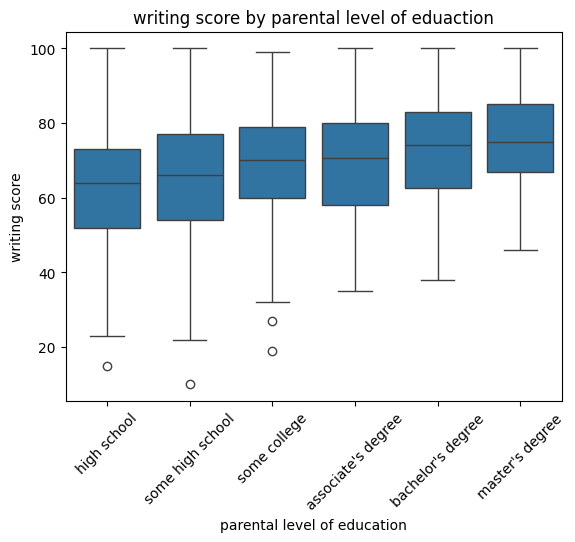

In [19]:
#showing the means using  boxplots
subjects = ['math score','reading score','writing score']

for subject in subjects:
    sns.boxplot(
        x='parental level of education',
        y = subject,
        data = df,
        order = edu_means_sorted.index
    )
    plt.xticks(rotation = 45)
    plt.title(f"{subject} by parental level of eduaction")
    plt.show()

In [20]:
#performing the ANOVA test since there are more than 2 groups
from scipy.stats import f_oneway

for subject in subjects:
    groups = [
        df[df['parental level of education'] == level][subject]
        for level in df['parental level of education'].unique()
        ]
    
    f_stat,p_val = f_oneway(*groups)
    print(f"{subject}:p-value = {p_val:.5f}")

math score:p-value = 0.00001
reading score:p-value = 0.00000
writing score:p-value = 0.00000


### Impact of Parental Level of Education
- Student performance improves as parental education level increases.
- The highest average scores are observed among students whose parents have a master’s or bachelor’s degree.
- ANOVA results show that differences in mean scores across education levels are statistically significant.


In [21]:
#how does being in one group affect a students performance
print("This are the available groups:")
df['race/ethnicity'].value_counts()

This are the available groups:


race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [22]:
#means across the different groups 
group_means = df.groupby('race/ethnicity')[['math score','reading score','writing score']].mean()
group_means

,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


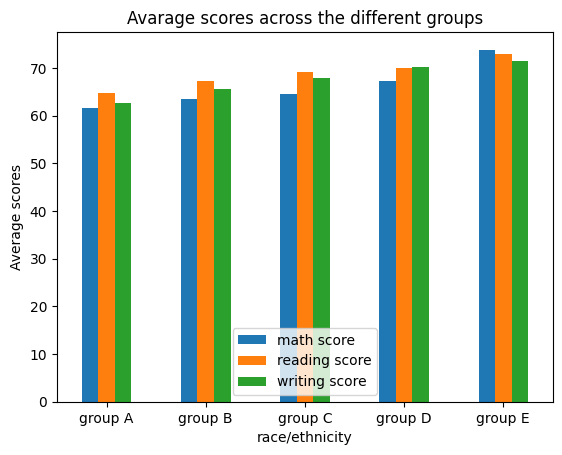

In [23]:
#visualizing the average performnace
group_means.plot(kind = 'bar')
plt.title('Avarage scores across the different groups')
plt.ylabel('Average scores')
plt.xticks(rotation = 0 )
plt.show()

In [24]:
#finding the overal mean per group and ranking from highest to lowest
group_means["overall average"] = group_means.mean(axis=1)
group_means.sort_values(by="overall average", ascending=False)


,math score,reading score,writing score,overall average
race/ethnicity,,,,
group E,73.821429,73.028571,71.407143,72.752381
group D,67.362595,70.030534,70.145038,69.179389
group C,64.463950,69.103448,67.827586,67.131661
group B,63.452632,67.352632,65.600000,65.468421
group A,61.629213,64.674157,62.674157,62.992509


<Figure size 800x500 with 0 Axes>

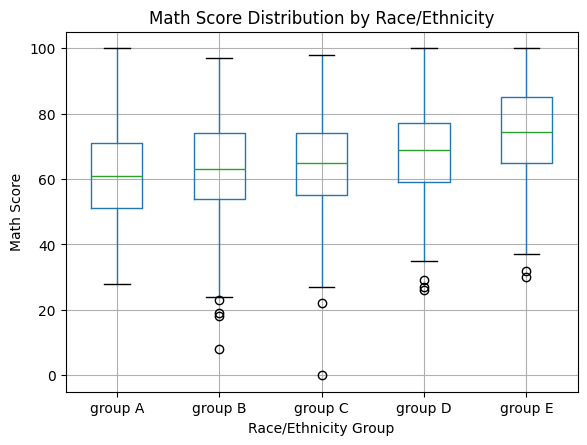

In [25]:
plt.figure(figsize=(8,5))
df.boxplot(column="math score", by="race/ethnicity")
plt.title("Math Score Distribution by Race/Ethnicity")
plt.suptitle("")  # removes automatic title
plt.xlabel("Race/Ethnicity Group")
plt.ylabel("Math Score")
plt.show()


<Figure size 800x500 with 0 Axes>

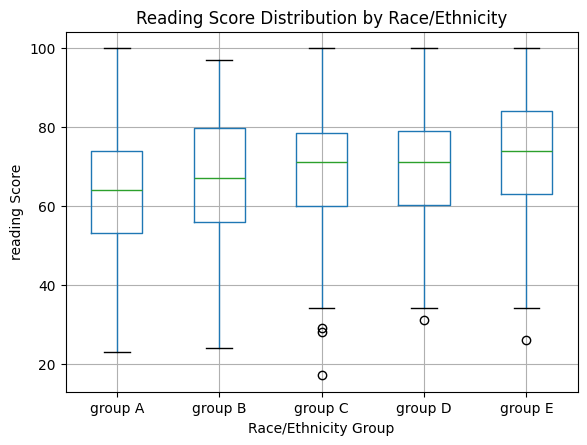

In [26]:
plt.figure(figsize=(8,5))
df.boxplot(column="reading score", by="race/ethnicity")
plt.title("Reading Score Distribution by Race/Ethnicity")
plt.suptitle("")  # removes automatic title
plt.xlabel("Race/Ethnicity Group")
plt.ylabel("reading Score")
plt.show()


<Figure size 800x500 with 0 Axes>

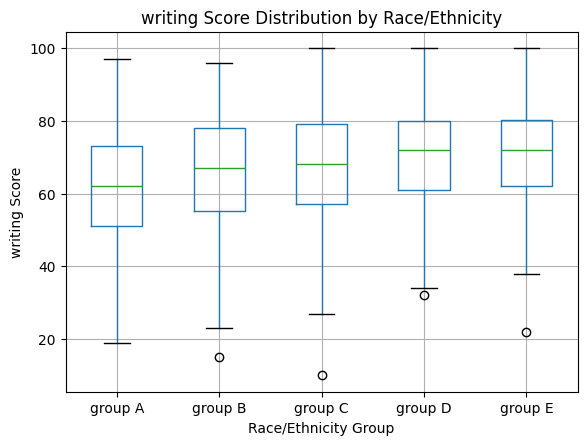

In [27]:
plt.figure(figsize=(8,5))
df.boxplot(column="writing score", by="race/ethnicity")
plt.title("writing Score Distribution by Race/Ethnicity")
plt.suptitle("")  # removes automatic title
plt.xlabel("Race/Ethnicity Group")
plt.ylabel("writing Score")
plt.show()


In [28]:
#doing the anova test to check if means are same or not
from scipy.stats import f_oneway

for subject in subjects:
    groups = [
        df[df['race/ethnicity'] == level][subject]
        for level in df['race/ethnicity'].unique()
        ]
    
    f_stat,p_val = f_oneway(*groups)
    print(f"{subject}:p-value = {p_val:.5f}")


math score:p-value = 0.00000
reading score:p-value = 0.00018
writing score:p-value = 0.00001


### Impact of Race on student performance
The analysis shows that the average student performance varies across the race groups.Group E generally records the highes mean scores across the three subjects while group A shows lower averages.

ANOVA tests show statistically significant differences in math,reading and writing scores since (p_val<0.05) showing that performance is associated with race/ethnicity group.

In [29]:
#how does the lunch type affect student performance
df['lunch'].value_counts()

lunch
standard        645
free/reduced    355
Name: count, dtype: int64

In [30]:
lunch_type_means = df.groupby('lunch')[['math score','reading score','writing score']].mean()
lunch_type_means

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


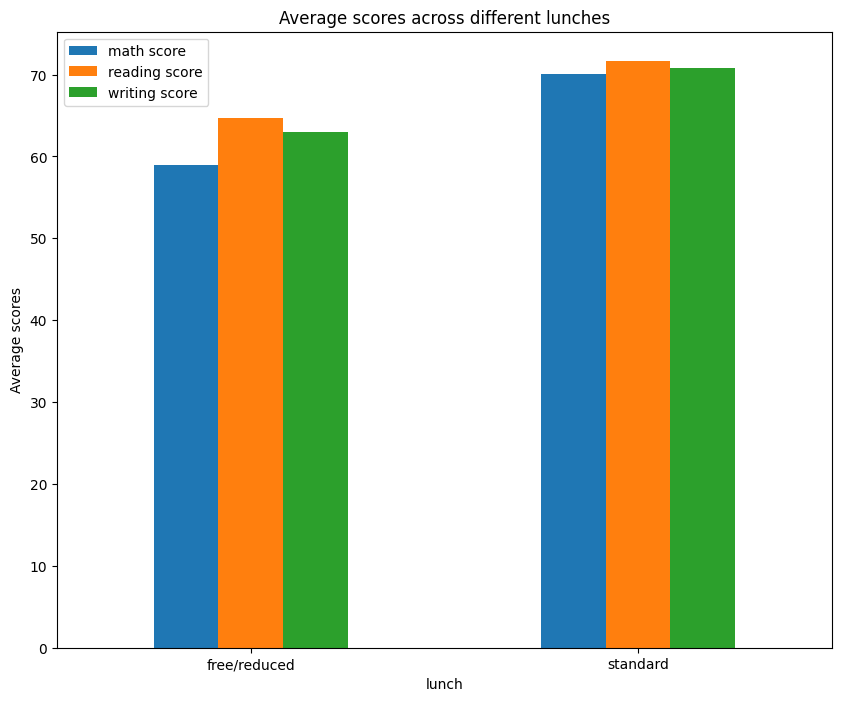

In [31]:
lunch_type_means.plot(kind = 'bar', figsize=(10,8))
plt.title('Average scores across different lunches')
plt.ylabel('Average scores')
plt.xticks(rotation = 0)
plt.show()

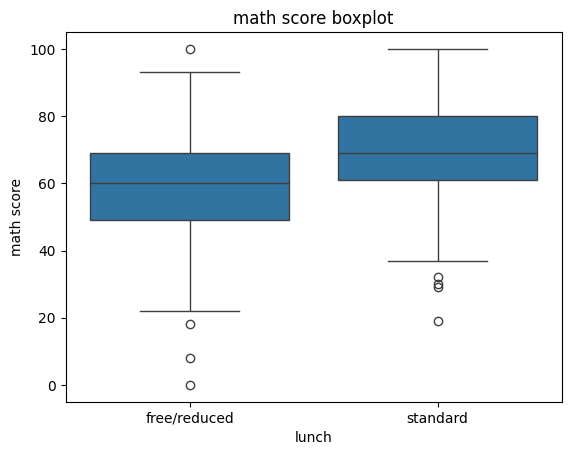

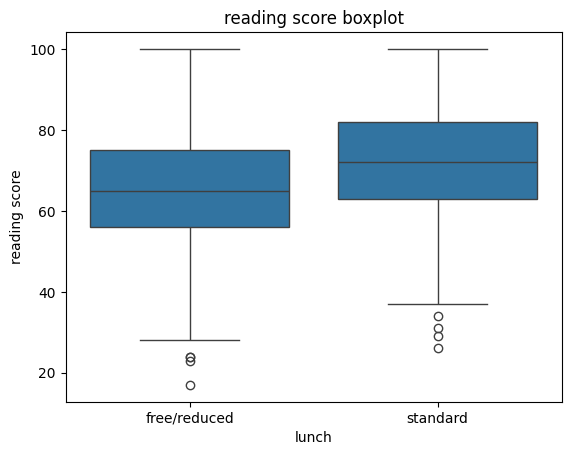

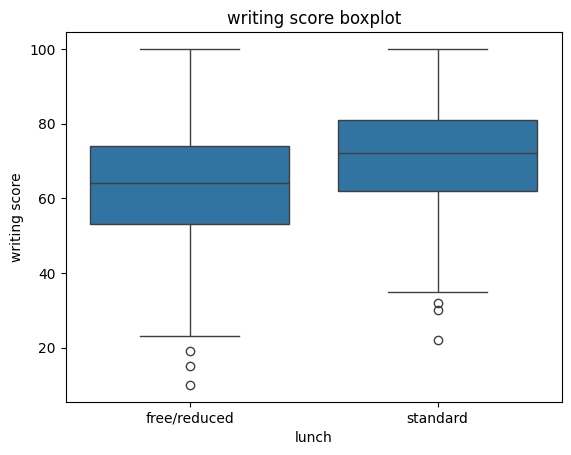

In [32]:
#using boxplots to show the difference in the means
for subject in subjects:
    sns.boxplot(x = 'lunch', y = subject , data = df,order = lunch_type_means.index)
    plt.xticks(rotation=0)
    plt.title(f'{subject} boxplot')
    plt.show()

In [33]:
#anova test
from scipy.stats import f_oneway

for subject in subjects:
    groups = [df[df['lunch'] == level][subject]
            for level in df['lunch'].unique()
            ]
    f_val,p_val = f_oneway(*groups)
    print(f"{subject}:p-value = {p_val:.5f}")


math score:p-value = 0.00000
reading score:p-value = 0.00000
writing score:p-value = 0.00000


### Effect of different lunch type on student performance

-Ideally, students who take in the standard lunch type score higher complared to those who take free/reduced lunch

-This has been proven statistically throught the anova test as (p_val<0.05) for all subjects implying that there are significant differences

-Beyond statistical significance, the observed differences in mean scores indicate a practically meaningful gap in performance.

This suggests that socioeconomic factors associated with lunch type may play an important role in academic achievement.